# Zaawansowana klasyfikacja

## Dane numeryczne - Klasyfikacja za pomocą SVM

In [3]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


Zadanie wariant 14

Rozkład klas w wygenerowanym zbiorze:
Klasa 0: 381, Klasa 1: 119

================ SVM (zbalansowany) ================
Ogólne Accuracy: 0.9800
              precision    recall  f1-score   support

     Klasa 0       1.00      0.97      0.99        80
     Klasa 1       0.91      1.00      0.95        20

    accuracy                           0.98       100
   macro avg       0.95      0.99      0.97       100
weighted avg       0.98      0.98      0.98       100



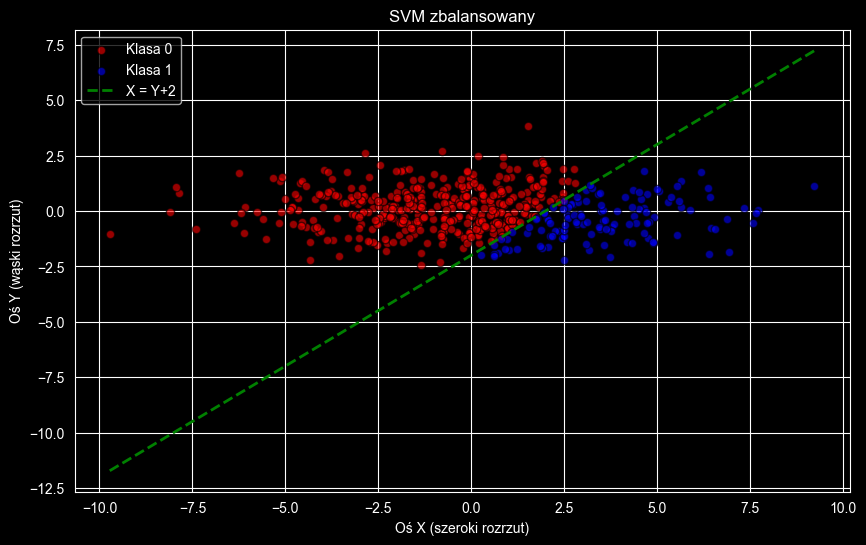

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

np.random.seed(42)
X = np.random.randn(500, 2) * [3, 1]
y = (X[:, 0] > X[:, 1]+2).astype(int)

print("Rozkład klas w wygenerowanym zbiorze:")
print(f"Klasa 0: {np.sum(y == 0)}, Klasa 1: {np.sum(y == 1)}\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#model = SVC(kernel='linear')
model = SVC(kernel='linear', class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("================ SVM (zbalansowany) ================")
print(f"Ogólne Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Klasa 0', 'Klasa 1']))

plt.figure(figsize=(10, 6))

# Wykres punktowy dla obu klas
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', alpha=0.6, label='Klasa 0', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', alpha=0.6, label='Klasa 1', edgecolors='k')

# Rysowanie prostej podziału X0 = X1 (teoretyczna granica zdefiniowana w zadaniu)
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
plt.plot(x_vals, x_vals-2, 'g--', linewidth=2, label='X = Y+2')

plt.title("SVM zbalansowany")
plt.xlabel("Oś X (szeroki rozrzut)")
plt.ylabel("Oś Y (wąski rozrzut)")
plt.legend()
plt.grid(True)
plt.show()